(301,)
(201,)
epsilon=10.100000000000001 delta=7.8 chi=-0.1 kappa=1.0
[-6.24224667  9.33422409] [ -8.84463384 -10.02167929]
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          5.91e+00       9.54e-01         10001          10000     
       2          9.64e+00       3.52e-01         20001          20000     
       3          4.89e+00       1.20e+00         40001          30010     
       4          1.03e+00       5.28e-01         70011          14813     
       5          1.18e-01       1.69e-01         84824           68       
       6          7.71e-04       4.17e-02         84892            0       
Solved in 6 iterations, number of nodes 84892. 
Maximum relative residual: 7.71e-04 
Maximum boundary residual: 4.17e-02


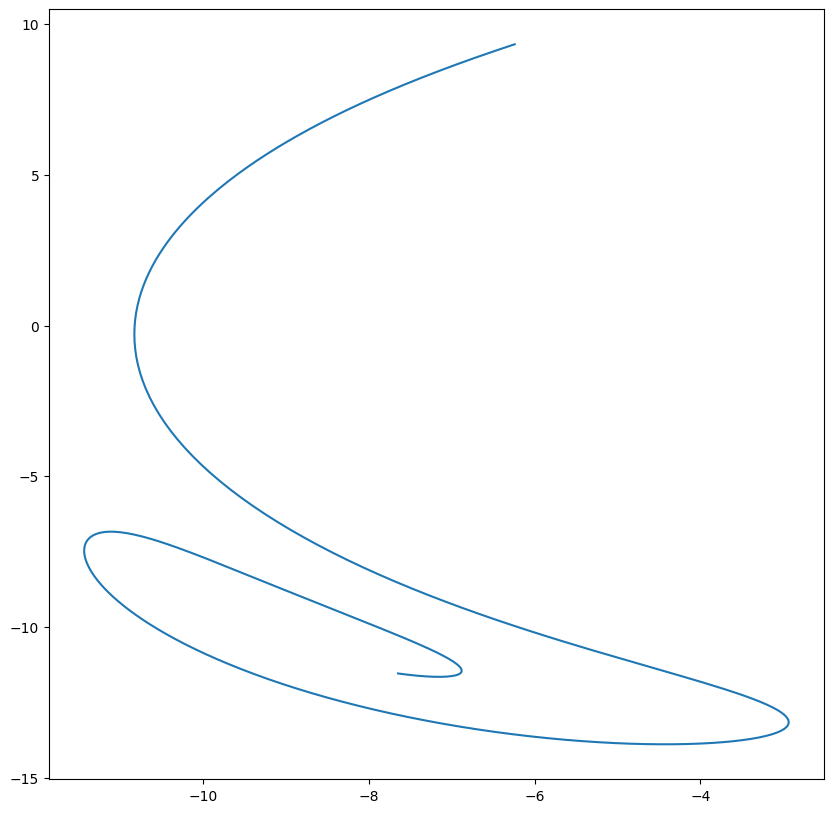

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  1.000e-04 ...  8.000e+00  8.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7fc4c8599210>
             p: None
             y: [[-7.651e+00 -7.650e+00 ... -6.242e+00 -6.242e+00]
                 [-1.154e+01 -1.154e+01 ...  9.334e+00  9.334e+00]
                 [-1.590e-01 -1.587e-01 ...  5.951e-08  5.948e-08]
                 [-4.877e-01 -4.876e-01 ... -4.337e-08 -4.334e-08]]
            yp: [[ 7.671e+00  7.668e+00 ...  4.112e-08  4.082e-08]
                 [-2.931e+00 -2.927e+00 ...  1.878e-07  1.876e-07]
                 [ 2.158e+00  2.159e+00 ... -1.831e-07 -1.830e-07]
                 [ 1.419e+00  1.421e+00 ...  1.334e-07  1.334e-07]]
 rms_residuals: [ 2.373e-04  2.373e-04 ...  5.829e-12  7.572e-12]
         niter: 6


In [27]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/00-attempt/map.npz")
epsilon_idx = 101
kappa_idx = 40
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def boundary_condition_func(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, boundary_condition_func, t_guess, y_guess, tol=1e-1, max_nodes=1000000, verbose=2
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(10, 10))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

print(res)

In [29]:
array = np.array([res])

In [31]:
np.savez("paths.npz", array=array)

In [32]:
ls

1.py  display-map.py  generate-map.py      map-601x401.npz  paths.npz
2.py  fig.png         generate-path.ipynb  map.npz
